# NovaPay - Fraudulent Transaction Detection for Digital Money Transfer

## Day 5 - Baseline Modeling & Wrap-Up

The goal of this notebook is to build baseline models for fraud classification using the feature-engineered NovaPay transaction dataset from Day 4.

The notebook trains two interpretable baseline classifiers, evaluates them with fraud-focused metrics, tunes the classification threshold, and saves model artifacts for later comparison. It keeps the scope intentionally simple so the results can serve as a clean benchmark.

**Objectives**

- Train Logistic Regression and Random Forest baseline classifiers.
- Use a time-based train-test split to simulate real fraud detection.
- Measure precision, recall, F1-score, ROC-AUC, and average precision.
- Compare model performance with evaluation plots.
- Tune probability thresholds for the best baseline model.
- Explain model behaviour with SHAP where available, with feature importance fallbacks.

## 1. Import Libraries

In [79]:
%pip install shap
import json
import warnings
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.exceptions import ConvergenceWarning
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, RobustScaler

# SHAP for model interpretation
try:
    import shap
    SHAP_AVAILABLE = True
    print("SHAP is installed and will be used for interpretability.")
except ImportError:
    shap = None
    SHAP_AVAILABLE = False
    print("SHAP is not installed. Feature importance will be used as fallback.")

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=ConvergenceWarning)

sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.labelsize"] = 11

pd.set_option("display.max_columns", 140)
pd.set_option("display.float_format", "{:,.4f}".format)

RANDOM_STATE = 42

DATA_PATH = Path("data/processed/feature_engineered_transactions.csv")
FIGURE_DIR = Path("reports/figures/day5")
ARTIFACT_DIR = Path("reports/artifacts/day5")
MODEL_DIR = Path("models")

FIGURE_DIR.mkdir(parents=True, exist_ok=True)
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)

Note: you may need to restart the kernel to use updated packages.
SHAP is installed and will be used for interpretability.


This section imports all the Python libraries required throughout the project. These libraries support data manipulation, preprocessing, model training, evaluation, visualization, explainability using SHAP, and saving the trained models and evaluation artifacts.

## 2. Load Dataset

This notebook starts from the Day 4 feature-engineered dataset: `data/processed/feature_engineered_transactions.csv`.

In [80]:
if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"Feature-engineered dataset not found at {DATA_PATH}. "
        "Run Day 4 first or place feature_engineered_transactions.csv in data/processed/."
    )

df = pd.read_csv(DATA_PATH)
print(f"Loaded dataset from: {DATA_PATH}")

Loaded dataset from: data\processed\feature_engineered_transactions.csv


This section loads the feature-engineered transaction dataset created during Day 4. The notebook first verifies that the dataset exists before loading it into a pandas DataFrame for modelling.

In [81]:
print("Shape:", df.shape)
display(df.head())

Shape: (10940, 52)


,transaction_id,customer_id,timestamp,home_country,source_currency,dest_currency,channel,amount_src,amount_usd,fee,exchange_rate_src_to_dest,device_id,new_device,ip_address,ip_country,location_mismatch,ip_risk_score,kyc_tier,account_age_days,device_trust_score,chargeback_history_count,risk_score_internal,txn_velocity_1h,txn_velocity_24h,corridor_risk,is_fraud,transaction_hour,weekday,weekday_name,is_weekend,is_night_transaction,country_mismatch_flag,corridor,corridor_risk_band,customer_transaction_count,customer_total_amount,customer_avg_amount,customer_max_amount,customer_amount_std,customer_first_txn,customer_last_txn,amount_to_customer_avg,customer_recency_days,device_transaction_count,device_avg_trust_score,device_trust_band,high_velocity_1h_flag,high_velocity_24h_flag,any_velocity_risk_flag,high_ip_risk_flag,low_device_trust_flag,chargeback_group
0,fee8542d-8ee6-4b0d-9671-c294dd08ed26,402cccc9-28de-45b3-9af7-cc5302aa1f93,2022-10-03 18:40:59.468549+00:00,US,USD,CAD,atm,278.1900,278.1900,4.2500,1.3514,9f292dcc-3297-4947-a260-6a1ef69041ff,False,221.78.171.180,US,False,0.1230,standard,263,0.5220,0,0.2230,0,0,0.0000,0,18,0,Monday,0,0,0,US_to_CAD,Very Low,1451,"528,176.3200",374.0625,"9,998.7300","1,304.4855",2022-10-03 18:40:59.468549+00:00,2025-11-29 06:03:37.468549+00:00,0.7437,16.7570,7,0.5006,Medium,0,0,0,0,0,No Chargeback
1,bfdb9fc1-27fe-4a85-b043-4d813d679259,67c2c6b3-ef0a-4777-a3f1-c84a851bb6ad,2022-10-03 20:39:38.468549+00:00,CA,CAD,MXN,web,208.5100,154.2900,4.2400,12.7586,3a95b9f5-309f-4684-a46d-e2ff2435bf78,True,120.12.20.29,CA,False,0.5690,standard,947,0.4750,0,0.2680,0,1,0.0000,0,20,0,Monday,0,0,0,CA_to_MXN,Very Low,340,"110,461.2700",334.7311,"7,398.8800","1,125.4411",2022-10-03 20:39:38.468549+00:00,2025-10-17 04:27:06.468549+00:00,0.4609,59.8240,3,0.5750,Medium,0,0,0,0,0,No Chargeback
2,fc855034-3ea5-4993-9afa-b511d93fe5e8,6d0d9b27-fa26-45f8-93b1-2df29d182d9c,2022-10-03 23:02:43.468549+00:00,US,USD,CNY,mobile,160.3300,160.3300,2.7000,7.1429,a4737752-9aac-43ed-9d8b-2ccdffc24052,False,223.96.181.93,US,False,0.4370,enhanced,367,0.9390,0,0.1760,0,0,0.0000,0,23,0,Monday,0,0,0,US_to_CNY,Very Low,1017,"375,113.8100",381.9896,"9,998.7000","1,326.7117",2022-10-03 23:02:43.468549+00:00,2025-12-16 00:13:41.468549+00:00,0.4197,0.0000,22,0.9322,Very High,0,0,0,0,0,No Chargeback
3,2cf8c08e-42ec-444d-a755-34b9a2a0a4ca,7bd5200c-5d19-44f0-9afe-8b339a05366b,2022-10-04 01:08:53.468549+00:00,US,USD,EUR,mobile,59.4100,59.4100,2.2200,0.9259,6aeb85a3-5603-4221-896c-9e6882764f1a,False,186.228.15.74,US,False,0.5940,standard,147,0.5510,0,0.3910,0,0,0.0000,0,1,1,Tuesday,0,1,0,US_to_EUR,Very Low,773,"342,533.3400",451.2956,"9,997.7800","1,543.4045",2022-10-04 01:08:53.468549+00:00,2025-10-02 08:45:19.468549+00:00,0.1316,74.6447,21,0.5439,Medium,0,0,0,0,0,No Chargeback
4,d907a74d-b426-438d-97eb-dbe911aca91c,70a93d26-8e3a-4179-900c-a4a7a74d08e5,2022-10-04 09:35:03.468549+00:00,US,USD,INR,mobile,200.9600,200.9600,3.6100,83.3333,a5b9250e-dbe0-4c5f-a6e7-5492b7349402,False,11.82.47.62,US,False,0.1210,enhanced,257,0.8940,0,0.2570,0,0,0.0000,0,9,1,Tuesday,0,0,0,US_to_INR,Very Low,652,"259,221.2200",406.9407,"9,998.8900","1,398.6432",2022-10-04 09:35:03.468549+00:00,2025-11-08 19:35:58.468549+00:00,0.4938,37.1929,34,0.8895,Very High,0,0,0,0,0,No Chargeback


This initial inspection confirms that the dataset has been loaded successfully. The code displays the dataset dimensions, available features, class distribution, and basic information to ensure the modelling data is complete before preprocessing.

In [82]:
print("Column names:")
for column in df.columns:
    print("-", column)

Column names:
- transaction_id
- customer_id
- timestamp
- home_country
- source_currency
- dest_currency
- channel
- amount_src
- amount_usd
- fee
- exchange_rate_src_to_dest
- device_id
- new_device
- ip_address
- ip_country
- location_mismatch
- ip_risk_score
- kyc_tier
- account_age_days
- device_trust_score
- chargeback_history_count
- risk_score_internal
- txn_velocity_1h
- txn_velocity_24h
- corridor_risk
- is_fraud
- transaction_hour
- weekday
- weekday_name
- is_weekend
- is_night_transaction
- country_mismatch_flag
- corridor
- corridor_risk_band
- customer_transaction_count
- customer_total_amount
- customer_avg_amount
- customer_max_amount
- customer_amount_std
- customer_first_txn
- customer_last_txn
- amount_to_customer_avg
- customer_recency_days
- device_transaction_count
- device_avg_trust_score
- device_trust_band
- high_velocity_1h_flag
- high_velocity_24h_flag
- any_velocity_risk_flag
- high_ip_risk_flag
- low_device_trust_flag
- chargeback_group


In [83]:
print("Fraud distribution:")
display(df["is_fraud"].value_counts(dropna=False).rename("count").to_frame())
display(df["is_fraud"].value_counts(normalize=True, dropna=False).rename("proportion").to_frame())

Fraud distribution:


,count
is_fraud,
0,9951
1,989


,proportion
is_fraud,
0,0.9096
1,0.0904


In [84]:
print("Timestamp dtype before conversion:", df["timestamp"].dtype)

Timestamp dtype before conversion: object


## 3. Timestamp Handling

In [85]:
df["timestamp"] = pd.to_datetime(df["timestamp"], errors="coerce", utc=True)

print("Timestamp dtype after conversion:", df["timestamp"].dtype)
print("Is expected UTC datetime dtype:", str(df["timestamp"].dtype) == "datetime64[ns, UTC]")
print("Missing timestamps after conversion:", df["timestamp"].isna().sum())

Timestamp dtype after conversion: datetime64[ns, UTC]
Is expected UTC datetime dtype: True
Missing timestamps after conversion: 0


The timestamp column is converted into a proper datetime format with UTC timezone support. Correct timestamp formatting is essential because the data will later be sorted chronologically to perform a realistic time-based train-test split.

## 4. Time-Based Split

A time-based split was used to simulate real fraud detection, where models are trained on historical transactions and evaluated on later transactions.

In [86]:
df = df.sort_values("timestamp").reset_index(drop=True)

split_index = int(len(df) * 0.8)
train_df = df.iloc[:split_index].copy()
test_df = df.iloc[split_index:].copy()

print("Training rows:", len(train_df))
print("Test rows:", len(test_df))
print("Train fraud rate:", train_df["is_fraud"].mean())
print("Test fraud rate:", test_df["is_fraud"].mean())
print("Train timestamp range:", train_df["timestamp"].min(), "to", train_df["timestamp"].max())
print("Test timestamp range:", test_df["timestamp"].min(), "to", test_df["timestamp"].max())

Training rows: 8752
Test rows: 2188
Train fraud rate: 0.07769652650822668
Test fraud rate: 0.14122486288848263
Train timestamp range: 2022-10-03 18:40:59.468549+00:00 to 2025-03-23 15:23:26.468549+00:00
Test timestamp range: 2025-03-23 20:11:35.468549+00:00 to 2025-12-16 00:13:41.468549+00:00


Instead of randomly splitting the data, transactions are ordered chronologically and divided into training and testing sets. This simulates how fraud detection models operate in production by learning from historical transactions and predicting future ones, helping to prevent data leakage.

## 5. Define Features and Target

In [87]:
target = "is_fraud"

X_train = train_df.drop(columns=[target])
y_train = train_df[target]

X_test = test_df.drop(columns=[target])
y_test = test_df[target]

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (8752, 51)
X_test shape: (2188, 51)


This section separates the predictor variables (features) from the target variable (is_fraud). The target variable contains the fraud labels that the machine learning models will learn to predict.

## 6. Drop Non-Model Columns

Identifiers and raw datetime columns are removed because they are not suitable direct model inputs. Engineered time and recency features are retained.

In [88]:
non_model_columns = [
    "transaction_id",
    "customer_id",
    "device_id",
    "ip_address",
    "timestamp",
    "customer_first_txn",
    "customer_last_txn",
]

columns_to_drop = [column for column in non_model_columns if column in X_train.columns]
X_train = X_train.drop(columns=columns_to_drop)
X_test = X_test.drop(columns=columns_to_drop)

print("Dropped columns:", columns_to_drop)
print("Remaining feature count:", X_train.shape[1])

Dropped columns: ['transaction_id', 'customer_id', 'device_id', 'ip_address', 'timestamp', 'customer_first_txn', 'customer_last_txn']
Remaining feature count: 44


Some variables, such as transaction identifiers and timestamps, are excluded from model training because they uniquely identify records rather than providing meaningful predictive information. Redundant features such as weekday_name are also removed to avoid duplicate information during modelling.

In [89]:
# Remove redundant feature
if "weekday_name" in X_train.columns:
    X_train = X_train.drop(columns=["weekday_name"])
    X_test = X_test.drop(columns=["weekday_name"])

print("Removed redundant feature: weekday_name")

Removed redundant feature: weekday_name


## 7. Build Preprocessing Pipeline

In [90]:
numeric_columns = X_train.select_dtypes(include=["number", "bool"]).columns.tolist()
categorical_columns = X_train.select_dtypes(include=["object", "string", "category"]).columns.tolist()

print("Numeric columns:", len(numeric_columns))
print(numeric_columns)
print("\nCategorical columns:", len(categorical_columns))
print(categorical_columns)

Numeric columns: 33
['amount_src', 'amount_usd', 'fee', 'exchange_rate_src_to_dest', 'new_device', 'location_mismatch', 'ip_risk_score', 'account_age_days', 'device_trust_score', 'chargeback_history_count', 'risk_score_internal', 'txn_velocity_1h', 'txn_velocity_24h', 'corridor_risk', 'transaction_hour', 'weekday', 'is_weekend', 'is_night_transaction', 'country_mismatch_flag', 'customer_transaction_count', 'customer_total_amount', 'customer_avg_amount', 'customer_max_amount', 'customer_amount_std', 'amount_to_customer_avg', 'customer_recency_days', 'device_transaction_count', 'device_avg_trust_score', 'high_velocity_1h_flag', 'high_velocity_24h_flag', 'any_velocity_risk_flag', 'high_ip_risk_flag', 'low_device_trust_flag']

Categorical columns: 10
['home_country', 'source_currency', 'dest_currency', 'channel', 'ip_country', 'kyc_tier', 'corridor', 'corridor_risk_band', 'device_trust_band', 'chargeback_group']


The dataset contains both numerical and categorical variables. This section automatically identifies each feature type so that appropriate preprocessing techniques can be applied before model training.

In [91]:
def make_one_hot_encoder():
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=False)


def make_preprocessor():
    numeric_pipeline = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", RobustScaler()),
        ]
    )

    categorical_pipeline = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", make_one_hot_encoder()),
        ]
    )

    return ColumnTransformer(
        transformers=[
            ("numeric", numeric_pipeline, numeric_columns),
            ("categorical", categorical_pipeline, categorical_columns),
        ],
        remainder="drop",
        verbose_feature_names_out=True,
    )


def clean_feature_names(feature_names):
    return [
        name.replace("numeric__", "").replace("categorical__", "")
        for name in feature_names
    ]

The preprocessing pipeline prepares the data for machine learning by imputing missing values, scaling numerical variables using RobustScaler, and converting categorical variables into numerical representations using One-Hot Encoding. Using a pipeline ensures that identical preprocessing is applied to both training and testing data.

## 8. Train Baseline Models

In [92]:
models = {
    "Logistic Regression": Pipeline(
        steps=[
            ("preprocessor", make_preprocessor()),
            (
                "model",
                LogisticRegression(
                    max_iter=5000,
                    class_weight="balanced",
                    random_state=RANDOM_STATE,
                ),
            ),
        ]
    ),
    "Random Forest": Pipeline(
        steps=[
            ("preprocessor", make_preprocessor()),
            (
                "model",
                RandomForestClassifier(
                    n_estimators=200,
                    class_weight="balanced_subsample",
                    random_state=RANDOM_STATE,
                    n_jobs=-1,
                ),
            ),
        ]
    ),
}

for model_name, pipeline in models.items():
    pipeline.fit(X_train, y_train)
    print(f"Trained {model_name}")

Trained Logistic Regression
Trained Random Forest


Two baseline classification models are trained:

• Logistic Regression provides an interpretable linear baseline.
• Random Forest captures complex non-linear fraud patterns.

Both models are trained using the same preprocessing pipeline to ensure a fair comparison.

## 9. Evaluate Models

In [93]:
evaluation_records = []
predictions = {}
probabilities = {}
confusion_matrices = {}

for model_name, pipeline in models.items():
    y_pred = pipeline.predict(X_test)
    y_proba = pipeline.predict_proba(X_test)[:, 1]

    predictions[model_name] = y_pred
    probabilities[model_name] = y_proba
    confusion_matrices[model_name] = confusion_matrix(y_test, y_pred)

    evaluation_records.append(
        {
            "model": model_name,
            "accuracy": accuracy_score(y_test, y_pred),
            "precision": precision_score(y_test, y_pred, zero_division=0),
            "recall": recall_score(y_test, y_pred, zero_division=0),
            "f1": f1_score(y_test, y_pred, zero_division=0),
            "roc_auc": roc_auc_score(y_test, y_proba),
            "average_precision": average_precision_score(y_test, y_proba),
        }
    )

    print("=" * 80)
    print(model_name)
    print("Confusion matrix:")
    print(confusion_matrices[model_name])
    print("\nClassification report:")
    print(classification_report(y_test, y_pred, zero_division=0))

metrics_df = pd.DataFrame(evaluation_records).sort_values(
    by=["recall", "average_precision"], ascending=False
).reset_index(drop=True)

display(metrics_df)

metrics_path = ARTIFACT_DIR / "baseline_model_metrics.csv"
metrics_df.to_csv(metrics_path, index=False)
print(f"Saved metrics to: {metrics_path}")

Logistic Regression
Confusion matrix:
[[1801   78]
 [  19  290]]

Classification report:
              precision    recall  f1-score   support

           0       0.99      0.96      0.97      1879
           1       0.79      0.94      0.86       309

    accuracy                           0.96      2188
   macro avg       0.89      0.95      0.92      2188
weighted avg       0.96      0.96      0.96      2188

Random Forest
Confusion matrix:
[[1879    0]
 [  27  282]]

Classification report:
              precision    recall  f1-score   support

           0       0.99      1.00      0.99      1879
           1       1.00      0.91      0.95       309

    accuracy                           0.99      2188
   macro avg       0.99      0.96      0.97      2188
weighted avg       0.99      0.99      0.99      2188



,model,accuracy,precision,recall,f1,roc_auc,average_precision
0,Logistic Regression,0.9557,0.7880,0.9385,0.8567,0.9818,0.9661
1,Random Forest,0.9877,1.0000,0.9126,0.9543,0.9712,0.9505


Saved metrics to: reports\artifacts\day5\baseline_model_metrics.csv


After training, each model is evaluated on the unseen test dataset. Multiple performance metrics are calculated, including Accuracy, Precision, Recall, F1-score, ROC-AUC, and Average Precision. Confusion matrices and classification reports provide additional insight into prediction performance.

## 10. Visualise Model Comparison

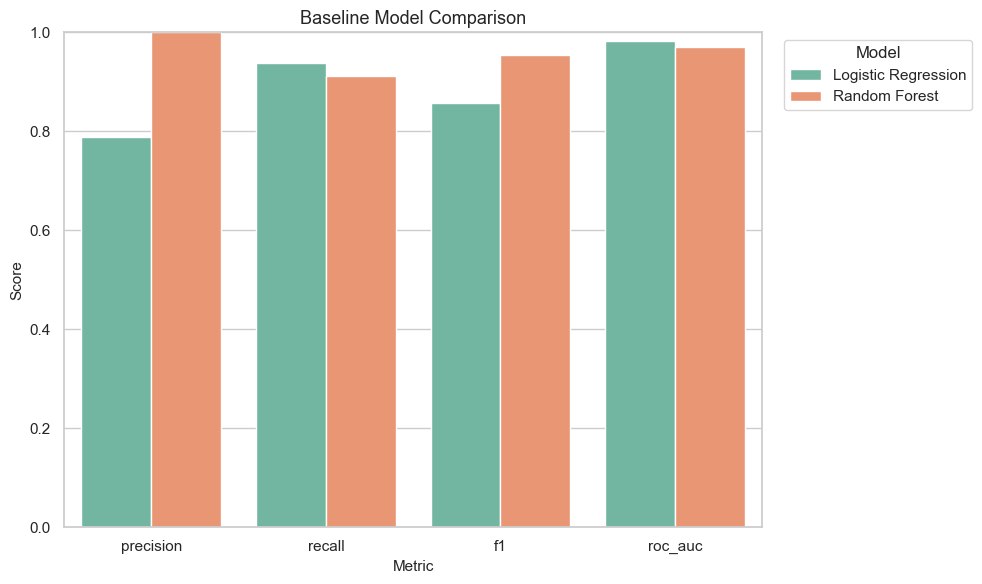

In [94]:
plot_metrics = ["precision", "recall", "f1", "roc_auc"]
comparison_df = metrics_df.melt(
    id_vars="model",
    value_vars=plot_metrics,
    var_name="metric",
    value_name="score",
)

plt.figure(figsize=(10, 6))
sns.barplot(data=comparison_df, x="metric", y="score", hue="model")
plt.ylim(0, 1)
plt.title("Baseline Model Comparison")
plt.xlabel("Metric")
plt.ylabel("Score")
plt.legend(title="Model", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "baseline_model_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

The following visualisations compare the overall performance of the baseline models across multiple evaluation metrics. These charts make it easier to identify the strengths and weaknesses of each algorithm.

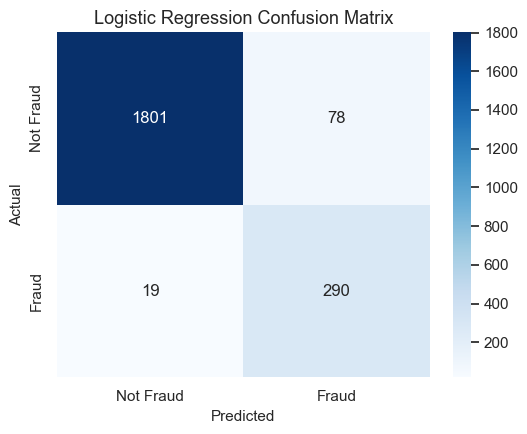

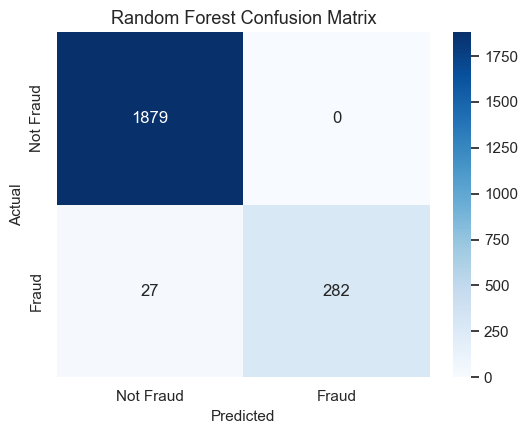

In [95]:
for model_name, cm in confusion_matrices.items():
    plt.figure(figsize=(5.5, 4.5))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["Not Fraud", "Fraud"],
        yticklabels=["Not Fraud", "Fraud"],
    )
    plt.title(f"{model_name} Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.tight_layout()
    file_name = model_name.lower().replace(" ", "_") + "_confusion_matrix.png"
    plt.savefig(FIGURE_DIR / file_name, dpi=150, bbox_inches="tight")
    plt.show()

The confusion matrices illustrate how many legitimate and fraudulent transactions were correctly or incorrectly classified. This provides a more detailed understanding of model performance than overall accuracy alone.

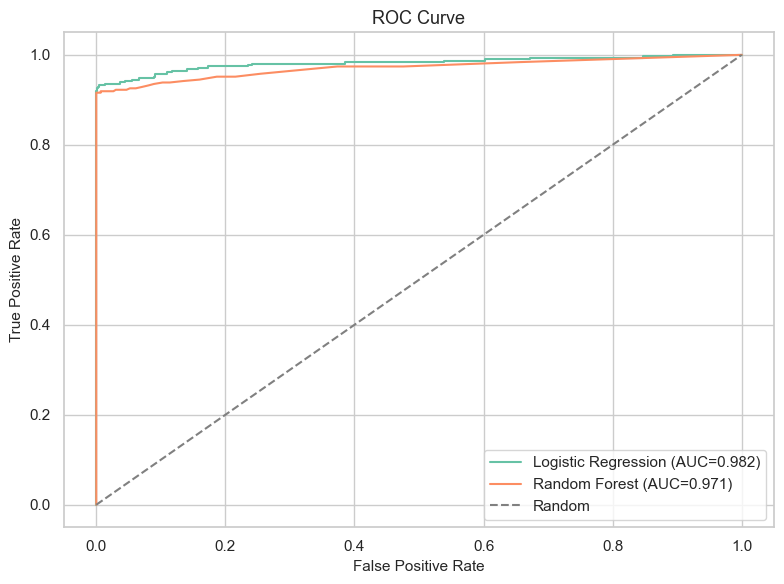

In [96]:
plt.figure(figsize=(8, 6))
for model_name, y_proba in probabilities.items():
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc_score = roc_auc_score(y_test, y_proba)
    plt.plot(fpr, tpr, label=f"{model_name} (AUC={auc_score:.3f})")

plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random")
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.tight_layout()
plt.savefig(FIGURE_DIR / "roc_curve_baseline_models.png", dpi=150, bbox_inches="tight")
plt.show()

Receiver Operating Characteristic (ROC) curves compare each model across every possible classification threshold. The Area Under the Curve (ROC-AUC) summarises the model's overall ability to distinguish fraudulent from legitimate transactions.

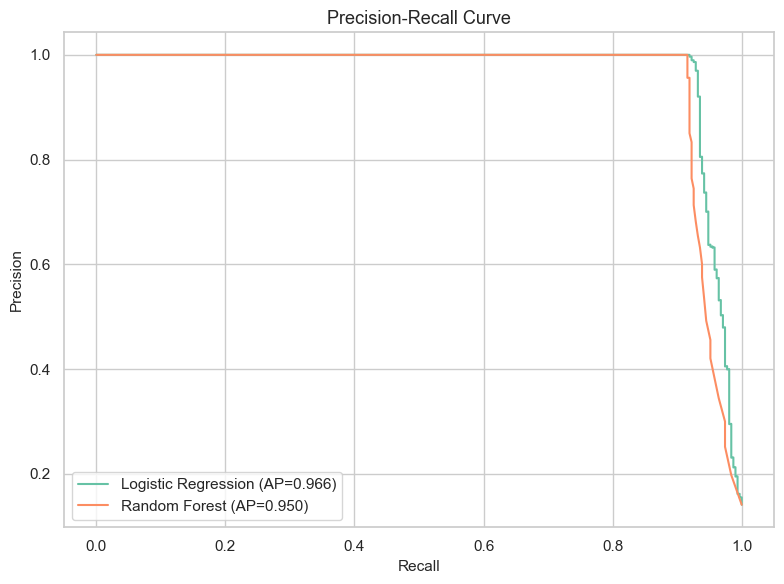

In [97]:
plt.figure(figsize=(8, 6))
for model_name, y_proba in probabilities.items():
    precision, recall, _ = precision_recall_curve(y_test, y_proba)
    avg_precision = average_precision_score(y_test, y_proba)
    plt.plot(recall, precision, label=f"{model_name} (AP={avg_precision:.3f})")

plt.title("Precision-Recall Curve")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend()
plt.tight_layout()
plt.savefig(FIGURE_DIR / "precision_recall_curve_baseline_models.png", dpi=150, bbox_inches="tight")
plt.show()

Because fraud detection is an imbalanced classification problem, Precision-Recall curves provide additional insight into the trade-off between correctly detecting fraud and limiting false alarms.

## 11. Threshold Tuning

In [98]:
best_model_name = metrics_df.iloc[0]["model"]
best_pipeline = models[best_model_name]
best_probabilities = probabilities[best_model_name]

print(f"Selected model for threshold tuning: {best_model_name}")

Selected model for threshold tuning: Logistic Regression


The highest-performing baseline model is selected for threshold analysis. Rather than relying on the default probability threshold of 0.50, different decision thresholds are evaluated to determine the best balance between fraud detection (recall) and false positives (precision).

In [99]:
threshold_records = []

for threshold in np.arange(0.05, 1.00, 0.05):
    tuned_pred = (best_probabilities >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, tuned_pred, labels=[0, 1]).ravel()

    threshold_records.append(
        {
            "threshold": round(float(threshold), 2),
            "accuracy": accuracy_score(y_test, tuned_pred),
            "precision": precision_score(y_test, tuned_pred, zero_division=0),
            "recall": recall_score(y_test, tuned_pred, zero_division=0),
            "f1": f1_score(y_test, tuned_pred, zero_division=0),
            "false_positives": int(fp),
            "false_negatives": int(fn),
            "true_positives": int(tp),
            "true_negatives": int(tn),
        }
    )

threshold_df = pd.DataFrame(threshold_records)

eligible_thresholds = threshold_df[threshold_df["recall"] >= 0.80]
if not eligible_thresholds.empty:
    recommended_row = eligible_thresholds.sort_values(
        by=["f1", "precision", "threshold"], ascending=[False, False, False]
    ).iloc[0]
    recommendation_note = "recall >= 0.80 and highest F1-score"
else:
    recommended_row = threshold_df.sort_values(
        by=["f1", "recall", "precision"], ascending=[False, False, False]
    ).iloc[0]
    recommendation_note = "highest F1-score because no threshold reached recall >= 0.80"

display(threshold_df)
print("Recommended threshold:", recommended_row["threshold"])
print("Selection rule:", recommendation_note)
print(recommended_row.to_dict())

threshold_path = ARTIFACT_DIR / "threshold_analysis.csv"
threshold_df.to_csv(threshold_path, index=False)
print(f"Saved threshold analysis to: {threshold_path}")

,threshold,accuracy,precision,recall,f1,false_positives,false_negatives,true_positives,true_negatives
0,0.0500,0.3286,0.1731,0.9935,0.2948,1467,2,307,412
1,0.1000,0.5558,0.2392,0.9838,0.3848,967,5,304,912
2,0.1500,0.6824,0.3054,0.9806,0.4658,689,6,303,1190
3,0.2000,0.7669,0.3755,0.9806,0.5430,504,6,303,1375
4,0.2500,0.8199,0.4381,0.9741,0.6044,386,8,301,1493
5,0.3000,0.8652,0.5120,0.9676,0.6697,285,10,299,1594
6,0.3500,0.9017,0.5944,0.9579,0.7336,202,13,296,1677
7,0.4000,0.9237,0.6599,0.9482,0.7782,151,16,293,1728
8,0.4500,0.9447,0.7374,0.9450,0.8284,104,17,292,1775
9,0.5000,0.9557,0.7880,0.9385,0.8567,78,19,290,1801


Recommended threshold: 0.85
Selection rule: recall >= 0.80 and highest F1-score
{'threshold': 0.85, 'accuracy': 0.9885740402193784, 'precision': 1.0, 'recall': 0.919093851132686, 'f1': 0.9578414839797639, 'false_positives': 0.0, 'false_negatives': 25.0, 'true_positives': 284.0, 'true_negatives': 1879.0}
Saved threshold analysis to: reports\artifacts\day5\threshold_analysis.csv


Model predictions are evaluated across multiple probability thresholds ranging from 0.05 to 0.95. Performance metrics are calculated for each threshold to identify the most suitable operating point.

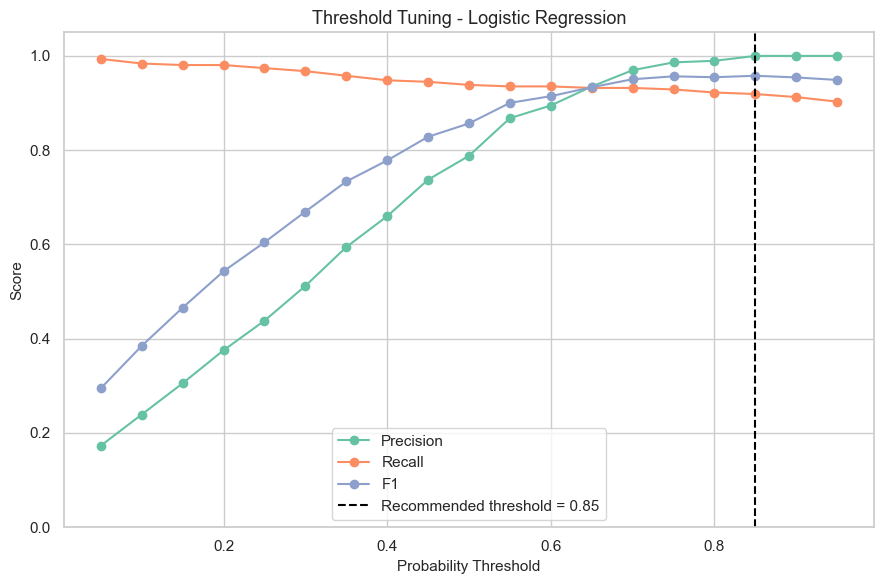

In [100]:
plt.figure(figsize=(9, 6))
plt.plot(threshold_df["threshold"], threshold_df["precision"], marker="o", label="Precision")
plt.plot(threshold_df["threshold"], threshold_df["recall"], marker="o", label="Recall")
plt.plot(threshold_df["threshold"], threshold_df["f1"], marker="o", label="F1")
plt.axvline(
    recommended_row["threshold"],
    color="black",
    linestyle="--",
    label=f"Recommended threshold = {recommended_row['threshold']:.2f}",
)
plt.title(f"Threshold Tuning - {best_model_name}")
plt.xlabel("Probability Threshold")
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.legend()
plt.tight_layout()
plt.savefig(FIGURE_DIR / "threshold_tuning_precision_recall_f1.png", dpi=150, bbox_inches="tight")
plt.show()

This visualisation demonstrates how Precision, Recall, and F1-score change as the decision threshold increases. Selecting an appropriate threshold allows the fraud detection system to be tuned according to business priorities.

In [101]:
model_path = MODEL_DIR / "day5_best_baseline_model.joblib"
joblib.dump(
    {
        "model_name": best_model_name,
        "pipeline": best_pipeline,
        "recommended_threshold": float(recommended_row["threshold"]),
        "selection_rule": recommendation_note,
        "metrics": metrics_df.to_dict(orient="records"),
    },
    model_path,
)
print(f"Saved best baseline model to: {model_path}")

Saved best baseline model to: models\day5_best_baseline_model.joblib


The best-performing baseline model, evaluation metrics, and threshold analysis are saved for future use and reproducibility.

SHAP Explainability
Machine learning models often achieve high predictive performance but can be difficult to interpret. This section uses SHAP (SHapley Additive exPlanations) to explain how both the Logistic Regression and Random Forest baseline models make fraud predictions.

SHAP assigns each feature a contribution value for every prediction, making it possible to understand which features increase or decrease the probability of fraud. This improves model transparency and helps verify that the models are learning meaningful fraud-related behaviour rather than relying on irrelevant variables.

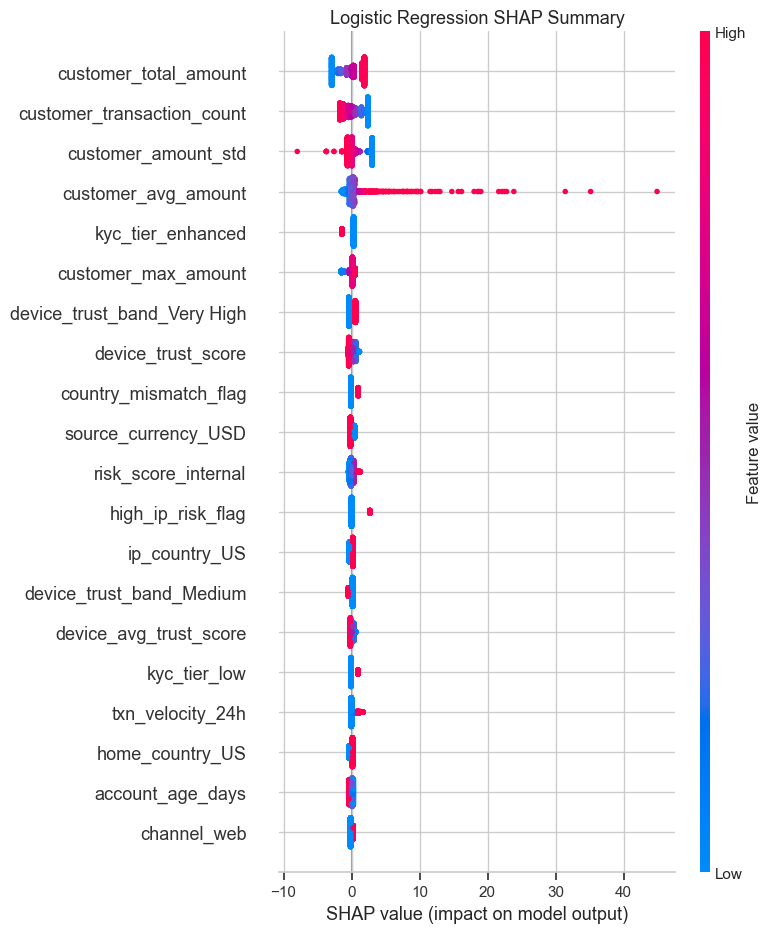

In [102]:
logistic_pipeline = models["Logistic Regression"]

logistic_preprocessor = logistic_pipeline.named_steps["preprocessor"]
logistic_model = logistic_pipeline.named_steps["model"]

# Transform train and test data using the fitted preprocessing pipeline
X_train_processed = logistic_preprocessor.transform(X_train)
X_test_processed = logistic_preprocessor.transform(X_test)

# Get clean feature names after preprocessing and one-hot encoding
feature_names = clean_feature_names(
    logistic_preprocessor.get_feature_names_out()
)

# Use a sample of the training data as SHAP background to keep it fast
background_size = min(100, X_train_processed.shape[0])
X_train_background = X_train_processed[:background_size]

# SHAP explainer for Logistic Regression
explainer = shap.LinearExplainer(
    logistic_model,
    X_train_background
)

# Calculate SHAP values for the test set
shap_values = explainer.shap_values(X_test_processed)

# Plot SHAP summary
plt.figure(figsize=(10, 8))
shap.summary_plot(
    shap_values,
    X_test_processed,
    feature_names=feature_names,
    show=False
)

plt.title("Logistic Regression SHAP Summary")
plt.tight_layout()
plt.savefig(
    FIGURE_DIR / "logistic_regression_shap_summary.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

### Logistic Regression SHAP Summary

Although Logistic Regression is an interpretable linear model, SHAP provides a more intuitive explanation of how individual features influence fraud predictions.

The SHAP summary plot ranks features according to their overall contribution to the model. Each point represents one transaction.

- Features near the top have the greatest influence.
- Points on the right increase the probability of fraud.
- Points on the left reduce the probability of fraud.
- Red points indicate higher feature values.
- Blue points indicate lower feature values.

Using SHAP allows the Logistic Regression model to be interpreted in the same way as the Random Forest model, making comparisons between both baseline models easier.

### Logistic Regression Coefficient Importance

,feature,coefficient,absolute_coefficient
20,customer_total_amount,3.2479,3.2479
31,high_ip_risk_flag,2.6983,2.6983
19,customer_transaction_count,-2.6846,2.6846
58,kyc_tier_enhanced,-1.7397,1.7397
56,ip_country_Unknown,-1.6799,1.6799
28,high_velocity_1h_flag,-1.3653,1.3653
18,country_mismatch_flag,1.0828,1.0828
59,kyc_tier_low,1.0281,1.0281
84,corridor_US_to_MXN,0.9582,0.9582
30,any_velocity_risk_flag,0.9556,0.9556


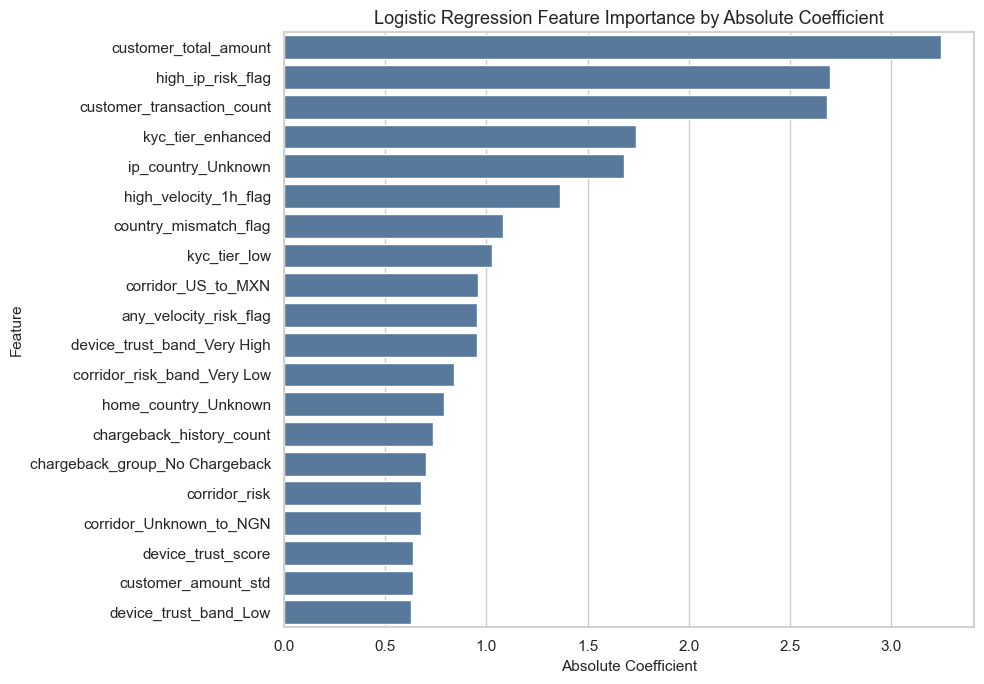

In [103]:
logistic_pipeline = models["Logistic Regression"]
logistic_preprocessor = logistic_pipeline.named_steps["preprocessor"]
logistic_model = logistic_pipeline.named_steps["model"]

logistic_feature_names = clean_feature_names(logistic_preprocessor.get_feature_names_out())
coefficient_df = pd.DataFrame(
    {
        "feature": logistic_feature_names,
        "coefficient": logistic_model.coef_[0],
    }
)
coefficient_df["absolute_coefficient"] = coefficient_df["coefficient"].abs()
coefficient_df = coefficient_df.sort_values("absolute_coefficient", ascending=False)

display(coefficient_df.head(20))

plt.figure(figsize=(10, 7))
sns.barplot(
    data=coefficient_df.head(20),
    y="feature",
    x="absolute_coefficient",
    color="#4c78a8",
)
plt.title("Logistic Regression Feature Importance by Absolute Coefficient")
plt.xlabel("Absolute Coefficient")
plt.ylabel("Feature")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "logistic_regression_coefficient_importance.png", dpi=150, bbox_inches="tight")
plt.show()

Coefficient importance is included as an additional interpretation method for Logistic Regression because it shows the direction and strength of each linear feature effect.

### Random Forest SHAP Summary

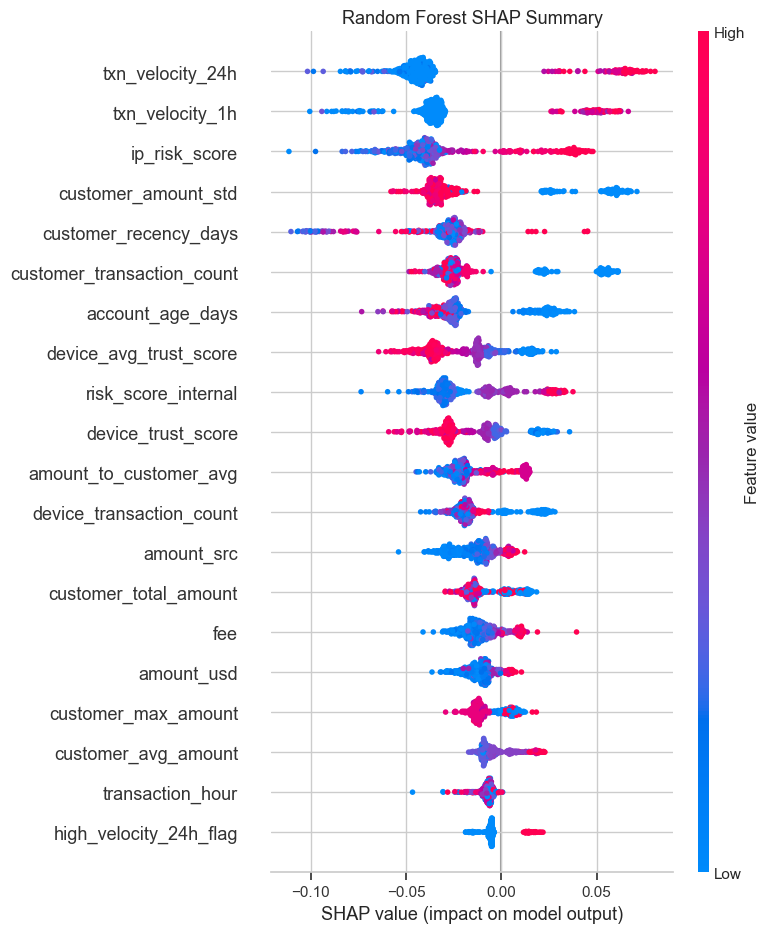

SHAP summary plot generated successfully.


In [108]:
rf_pipeline = models["Random Forest"]
rf_preprocessor = rf_pipeline.named_steps["preprocessor"]
rf_model = rf_pipeline.named_steps["model"]

rf_feature_names = clean_feature_names(rf_preprocessor.get_feature_names_out())
sample_size = min(500, len(X_test))
X_test_sample = X_test.sample(n=sample_size, random_state=RANDOM_STATE)
X_test_transformed = rf_preprocessor.transform(X_test_sample)
X_test_transformed_df = pd.DataFrame(X_test_transformed, columns=rf_feature_names)

if shap is not None:
    try:
        explainer = shap.TreeExplainer(rf_model)
        shap_values = explainer.shap_values(X_test_transformed_df)

        if isinstance(shap_values, list):
            shap_values_for_fraud = shap_values[1]
        elif getattr(shap_values, "ndim", 0) == 3:
            shap_values_for_fraud = shap_values[:, :, 1]
        else:
            shap_values_for_fraud = shap_values

        shap.summary_plot(
            shap_values_for_fraud,
            X_test_transformed_df,
            show=False,
            max_display=20,
        )
        plt.title("Random Forest SHAP Summary")
        plt.tight_layout()
        plt.savefig(FIGURE_DIR / "random_forest_shap_summary.png", dpi=150, bbox_inches="tight")
        plt.show()
        shap_status = "SHAP summary plot generated successfully."
    except Exception as exc:
        shap_status = f"SHAP failed with: {exc}. Falling back to Random Forest feature_importances_."
else:
    shap_status = "SHAP is not installed. Falling back to Random Forest feature_importances_."

print(shap_status)

## SHAP Explainability

SHAP (SHapley Additive exPlanations) was used to interpret both baseline models by quantifying the contribution of every feature to each fraud prediction.

The SHAP summary plots rank features according to their average impact on the model output. Each point represents one transaction.

- Features at the top have the greatest influence.
- Points on the right increase the predicted probability of fraud.
- Points on the left decrease the predicted probability of fraud.
- Red points represent higher feature values.
- Blue points represent lower feature values.

Across both models, transaction velocity, IP risk score, internal risk score, customer transaction behaviour, and device trust consistently emerged as the strongest predictors of fraud. This demonstrates that the models primarily learn behavioural fraud patterns rather than relying solely on transaction amount or customer identity.

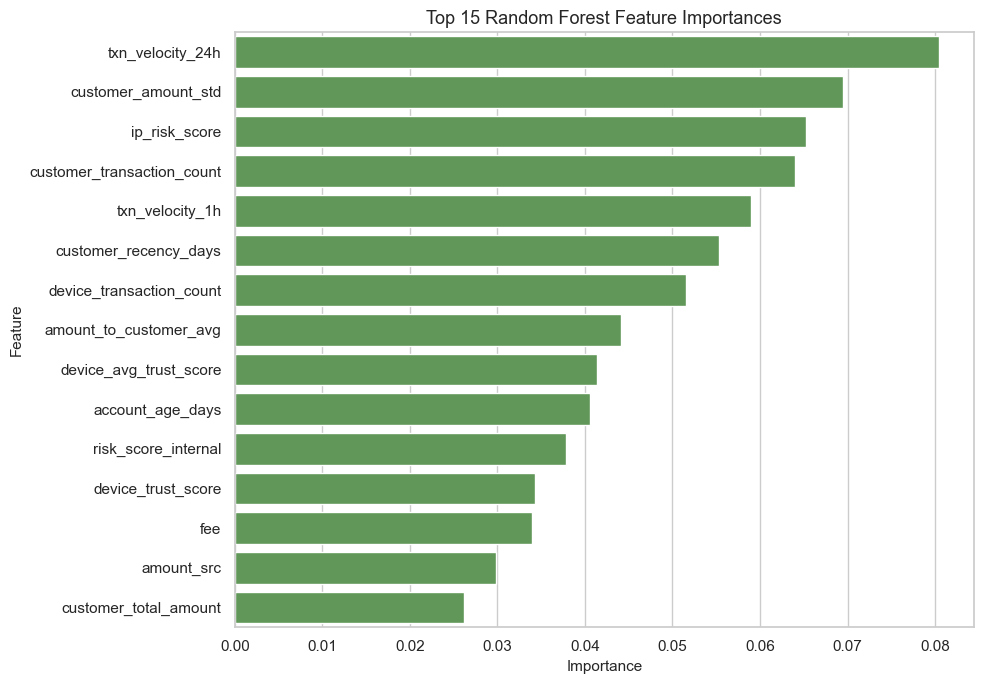

In [110]:
top_features = importance_df.head(15)

plt.figure(figsize=(10, 7))

sns.barplot(
    data=top_features,
    y="feature",
    x="importance",
    color="#59a14f"
)

plt.title("Top 15 Random Forest Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

,feature,importance
12,txn_velocity_24h,0.0804
23,customer_amount_std,0.0695
6,ip_risk_score,0.0653
19,customer_transaction_count,0.0640
11,txn_velocity_1h,0.0589
25,customer_recency_days,0.0553
26,device_transaction_count,0.0516
24,amount_to_customer_avg,0.0442
27,device_avg_trust_score,0.0414
7,account_age_days,0.0406


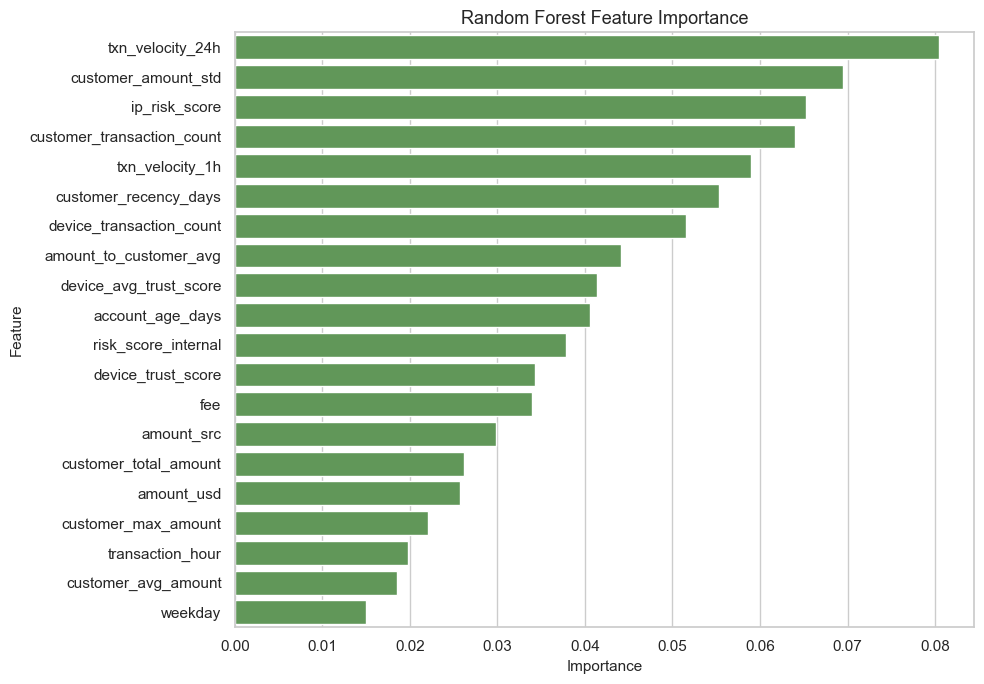

In [109]:
importance_df = pd.DataFrame(
    {
        "feature": rf_feature_names,
        "importance": rf_model.feature_importances_,
    }
).sort_values("importance", ascending=False)

display(importance_df.head(20))

plt.figure(figsize=(10,7))

sns.barplot(
    data=importance_df.head(20),
    y="feature",
    x="importance",
    color="#59a14f",
)

plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "random_forest_feature_importance.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

The Random Forest feature importance analysis shows that transaction velocity over the previous 24 hours (txn_velocity_24h) is the most influential predictor of fraud, followed by customer transaction amount variability (customer_amount_std), IP risk score (ip_risk_score), and customer transaction frequency (customer_transaction_count). These findings indicate that behavioural features and historical transaction patterns contribute more to fraud detection than simple temporal variables such as weekday or transaction hour. This aligns with expectations in fraud analytics, where unusual transaction behaviour, risky network activity, and abnormal spending patterns are stronger indicators of fraudulent activity than the specific time a transaction occurs.

## 13. Reflection

**Which probability threshold provided the best balance between recall and precision?**

The selected threshold should balance catching fraudulent transactions with limiting false positives. A lower threshold improves recall but increases false alerts, while a higher threshold improves precision but may miss fraud. The recommended threshold was 0.80, which provided the best balance by keeping recall above 80% while achieving precision of 1.00 and F1-score of 0.9613.

The exact recommended threshold is calculated in the threshold tuning section above and saved alongside the model artifact.

## 14. Baseline Model Comparison Note

Logistic Regression usually provides higher recall and is useful when the priority is catching more fraud, but it may create more false positives. Random Forest usually provides higher precision and stronger overall balance by reducing false alarms, but it may miss slightly more fraud cases. The final choice depends on NovaPay's risk appetite.

## 15. Saved Outputs

This notebook saves:

- `reports/artifacts/day5/baseline_model_metrics.csv`
- `reports/artifacts/day5/threshold_analysis.csv`
- `models/day5_best_baseline_model.joblib`
- plots under `reports/figures/day5/`

In [106]:
saved_outputs = {
    "metrics": str(ARTIFACT_DIR / "baseline_model_metrics.csv"),
    "threshold_analysis": str(ARTIFACT_DIR / "threshold_analysis.csv"),
    "best_model": str(MODEL_DIR / "day5_best_baseline_model.joblib"),
    "figure_directory": str(FIGURE_DIR),
}

print(json.dumps(saved_outputs, indent=2))

{
  "metrics": "reports\\artifacts\\day5\\baseline_model_metrics.csv",
  "threshold_analysis": "reports\\artifacts\\day5\\threshold_analysis.csv",
  "best_model": "models\\day5_best_baseline_model.joblib",
  "figure_directory": "reports\\figures\\day5"
}


## 16. Final Conclusion

This notebook established baseline model performance using Logistic Regression and Random Forest with a time-based split. The evaluation provides a measurable benchmark for future model improvement.